<a href="https://colab.research.google.com/github/dheep2305-git/Tsf-tasks/blob/main/tsf_task_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AR Coefficients: [ 1.28283997 -0.4512814  -0.20524637  0.04097632  0.00543007]
Prediction Error: 0.1731950353248718


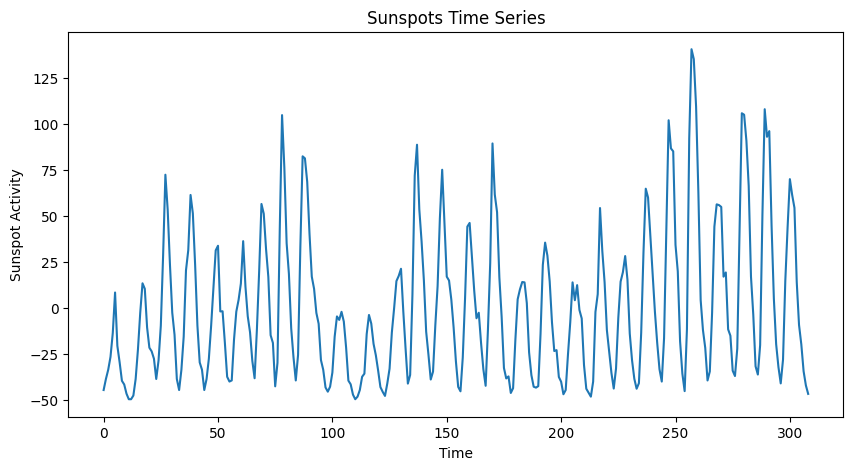

In [ ]:
# TASK 9
# Durbin-Levinson Algorithm

# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.datasets import sunspots

# Step 2: Load inbuilt dataset
data = sunspots.load_pandas().data

ts = data['SUNACTIVITY'].values

# Step 3: Preprocess (mean centering)
ts = ts - np.mean(ts)

# Step 4: Function to compute autocorrelation
def autocorr(x, lag):

    n = len(x)

    result = np.correlate(x, x, mode='full')

    acf = result[n-1:n+lag] / result[n-1]

    return acf


# Choose AR order
order = 5

# Compute autocorrelation values
r = autocorr(ts, order)


# Step 5 & 6: Durbin-Levinson Algorithm

def durbin_levinson(r, order):

    phi = np.zeros((order, order))

    E = np.zeros(order + 1)

    # Step 1 initialization
    phi[0, 0] = r[1] / r[0]

    E[1] = r[0] * (1 - phi[0, 0]**2)

    # Recursion
    for k in range(1, order):

        sum_val = sum(
            phi[k-1, j] * r[k-j]
            for j in range(k)
        )

        phi[k, k] = (
            r[k+1] - sum_val
        ) / E[k]

        for j in range(k):

            phi[k, j] = (
                phi[k-1, j]
                - phi[k, k] * phi[k-1, k-j-1]
            )

        E[k+1] = E[k] * (
            1 - phi[k, k]**2
        )

    return phi[order-1, :], E[order]


# Step 7: Get coefficients
coeffs, error = durbin_levinson(r, order)

# Step 8: Display results
print("AR Coefficients:", coeffs)

print("Prediction Error:", error)


# Optional: Plot the time series
plt.figure(figsize=(10, 5))
plt.plot(ts)

plt.title("Sunspots Time Series")
plt.xlabel("Time")
plt.ylabel("Sunspot Activity")

plt.show()